<a href="https://colab.research.google.com/github/RASIUT/ML/blob/main/DL/ANN/ANN_Churn_Modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Artificial Neural Network

##Import Libraries

In [22]:
import numpy as np
import pandas as pd
import tensorflow as tf

In [23]:
tf.__version__

'2.18.0'

#Data Preprocessing

##Import Datasets

In [24]:
df = pd.read_csv('Churn_Modelling.csv')
X = df.iloc[:, 3:-1].values
y = df.iloc[:, -1].values

In [25]:
print(X)

[[619 'France' 'Female' ... 1 1 101348.88]
 [608 'Spain' 'Female' ... 0 1 112542.58]
 [502 'France' 'Female' ... 1 0 113931.57]
 ...
 [709 'France' 'Female' ... 0 1 42085.58]
 [772 'Germany' 'Male' ... 1 0 92888.52]
 [792 'France' 'Female' ... 1 0 38190.78]]


In [26]:
print(y)

[1 0 1 ... 1 1 0]


##Encoding Categorical Data

###Label Encoding the "Gender" Column

In [27]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
X[:, 2] = le.fit_transform(X[:, 2])

In [28]:
print(X)

[[619 'France' 0 ... 1 1 101348.88]
 [608 'Spain' 0 ... 0 1 112542.58]
 [502 'France' 0 ... 1 0 113931.57]
 ...
 [709 'France' 0 ... 0 1 42085.58]
 [772 'Germany' 1 ... 1 0 92888.52]
 [792 'France' 0 ... 1 0 38190.78]]


###One Hot Encoding the "Geography" column

In [29]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
ct = ColumnTransformer(transformers=[('encoder', OneHotEncoder(), [1])], remainder='passthrough')
X = np.array(ct.fit_transform(X))

In [30]:
print(X)

[[1.0 0.0 0.0 ... 1 1 101348.88]
 [0.0 0.0 1.0 ... 0 1 112542.58]
 [1.0 0.0 0.0 ... 1 0 113931.57]
 ...
 [1.0 0.0 0.0 ... 0 1 42085.58]
 [0.0 1.0 0.0 ... 1 0 92888.52]
 [1.0 0.0 0.0 ... 1 0 38190.78]]


##Splitting the dataset into training and test set

In [31]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

##Feature Scaling

In [32]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

#Part 2: Building the ANN

##Initializing the ANN

In [33]:
ann = tf.keras.models.Sequential()

##Adding the input layer and the first hidden layer

In [34]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

##Adding the second hidden layer

In [35]:
ann.add(tf.keras.layers.Dense(units=6, activation='relu'))

##Adding the output layer

In [36]:
ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))

#Part 3: Training the ANN

##Compiling the ANN

In [37]:
ann.compile(optimizer = 'adam', loss = 'binary_crossentropy', metrics = ['accuracy'])


##Training the ANN on the training set

In [38]:
ann.fit(X_train, y_train, batch_size = 32, epochs = 100)

Epoch 1/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 2ms/step - accuracy: 0.6094 - loss: 0.6524
Epoch 2/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.7971 - loss: 0.4788
Epoch 3/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8073 - loss: 0.4568
Epoch 4/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8120 - loss: 0.4335
Epoch 5/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8169 - loss: 0.4141
Epoch 6/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8288 - loss: 0.4029
Epoch 7/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8277 - loss: 0.4037
Epoch 8/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8408 - loss: 0.3911
Epoch 9/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8421 - loss: 0.3854
Epoch 10/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8422 - loss: 0.3762
Epoch 11/100
250/250 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.8473 - loss: 0.3693
Epoch 12/100
250/250 ━━━━━━━━━━━━━━━━━━━━

#Part 4: Making predictions and evaluating the model

##Predicting the result of a single observation

In [41]:
print(ann.predict(sc.transform([[1, 0, 0, 600, 1, 40, 3, 60000, 2, 1, 1, 50000]])) > 0.5)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
[[False]]


##Predicting test set results

In [43]:
y_pred = ann.predict(X_test) > 0.5
y_pred_vector = y_pred.reshape(len(y_pred), 1)
y_test_vector = y_test.reshape(len(y_test), 1)
print(np.concatenate((y_pred_vector, y_test_vector), 1))

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step
[[0 0]
 [0 1]
 [0 0]
 ...
 [0 0]
 [0 0]
 [0 0]]


##Confusion matrix and Accuracy Score

In [44]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1522   73]
 [ 201  204]]


Text(50.72222222222221, 0.5, 'Actual')

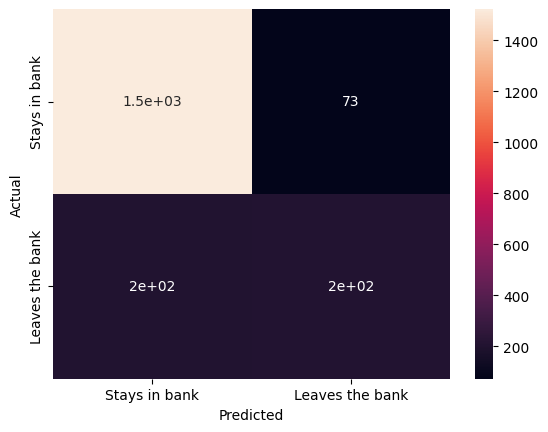

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(cm, annot=True, xticklabels=["Stays in bank", "Leaves the bank"], yticklabels=["Stays in bank", "Leaves the bank"])
plt.xlabel("Predicted")
plt.ylabel("Actual")

In [47]:
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test, y_pred))

0.863
